# 第三阶段：目标检测的核心机制 (Mini-YOLO 实战)

在前两课中，模型只需回答“图中是什么”。但在科研和工业界（如自动驾驶、医学影像），模型还必须回答“它在哪里”——这就是**目标检测（Object Detection）**。

真实世界的主流目标检测框架（如 YOLOv8）包含成千上万行代码和复杂的 Anchor/IoU 计算。为了让你在一节课内**彻底看懂目标检测的本质**，我们将手写一个“极简版单网格 YOLO”（Tiny-YOLO-1Cell），打通从数据到 ONNX 部署的全流程。

> **注意：** 所有文件现在统一保存在你指定的 `pytorch入门` 文件夹下。

## 步骤 1-3：数据集准备 ➔ Dataset ➔ DataLoader

### ① 知识讲解
目标检测的数据集除了图片，还必须附带标注文件（如 XML, JSON 或 TXT）。最著名的格式是 COCO 和 YOLO。每张图片对应多个目标的坐标：`[x_center, y_center, width, height, class_id]`。

### ② 为什么这么做
因为我们不仅要算分类的交叉熵，还要算预测框坐标与真实框坐标之间的距离（MSE）误差。

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ③ 完整代码 & ④ 代码逐行解释
# 为了让你能一键跑通，我们直接写一个“生成带框方块”的虚拟数据集
class FakeDetectionDataset(Dataset):
    def __init__(self, num_samples=100):
        self.num_samples = num_samples
        self.img_size = 112

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # 生成全黑背景图 (3 通道)
        img = np.zeros((3, self.img_size, self.img_size), dtype=np.float32)
        
        # 随机生成一个目标的宽、高和中心点
        w = np.random.randint(10, 30)
        h = np.random.randint(10, 30)
        cx = np.random.randint(w//2, self.img_size - w//2)
        cy = np.random.randint(h//2, self.img_size - h//2)
        
        # 将目标区域画成白色 (模拟目标)
        img[:, cy-h//2:cy+h//2, cx-w//2:cx+w//2] = 1.0
        
        # YOLO 格式坐标必须归一化到 [0, 1] 之间
        target_box = torch.tensor([
            cx / self.img_size,  # x_center
            cy / self.img_size,  # y_center
            w / self.img_size,   # width
            h / self.img_size    # height
        ], dtype=torch.float32)
        
        # 随机生成类别 (0: 假猫, 1: 假狗)
        label = torch.tensor(np.random.randint(0, 2), dtype=torch.long)
        return torch.tensor(img), target_box, label

train_loader = DataLoader(FakeDetectionDataset(500), batch_size=16, shuffle=True)
val_loader = DataLoader(FakeDetectionDataset(100), batch_size=16, shuffle=False)
print("虚拟目标检测数据集加载完毕！")

虚拟目标检测数据集加载完毕！


### 💡 深度避坑与实践建议
- **⑤ 容易踩坑**：最常见的错误是坐标格式不对！PyTorch 官方喜欢 `[x_min, y_min, x_max, y_max]`，而 YOLO 必须是 `[x_center, y_center, width, height]`。训练前一定要用可视化代码画个框确认一下坐标是否完全贴合！
- **⑥ 科研实验室**：处理真实检测数据极为繁杂。实验室通常用 `pycocotools` 直接解析 COCO 数据集，或者写脚本将所有格式统一转换为 YOLO 的 TXT 格式。
- **⑦ 工程实践建议**：检测任务的数据增强非常危险！如果你把图片水平翻转（RandomHorizontalFlip），你的真实框的 x 坐标必须同步翻转，否则会导致图片和框彻底错位。工程上统一使用专门为检测设计的 `Albumentations` 库，它会自动帮你翻转检测框。

## 步骤 4：模型搭建 (极简版 YOLO 头)

### ① 知识讲解
目标检测 = **分类（它是谁）** + **回归（它在哪）**。
我们要让神经网络最后输出一个综合向量：`[置信度(是否有物体), x, y, w, h, 类别1概率, 类别2概率]`。

### ② 为什么这么做
让一个神经网络同时做两件事（多任务学习 Multi-Task Learning），底层共享特征提取器（Backbone），最后通过不同的损失函数合并，逼迫模型同时学会找位置和认物体。

In [2]:
class MiniYOLO(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        # 1. 骨干网络 (Backbone)：依然用 ResNet 提取视觉特征
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1]) # 砍掉最后一层
        
        # 2. 检测头 (Detection Head)：将特征转化为 YOLO 向量
        # 输出维度 = 1(置信度) + 4(x,y,w,h) + num_classes(分类)
        self.head = nn.Linear(512, 1 + 4 + num_classes)
        
    def forward(self, x):
        features = self.backbone(x)      # [Batch, 512, 1, 1]
        features = features.view(-1, 512)# [Batch, 512]
        output = self.head(features)     # [Batch, 1 + 4 + num_classes]
        
        # 拆解预测结果
        # 置信度 (是否有目标) 使用 Sigmoid 压到 0~1 之间
        obj_conf = torch.sigmoid(output[:, 0]) 
        # 坐标框直接输出 (MSE 拟合)
        box_preds = torch.sigmoid(output[:, 1:5]) # 使用 Sigmoid 保证预测框坐标在 0~1 之间
        # 分类 logits (不需要激活，留给 CrossEntropyLoss)
        class_preds = output[:, 5:]
        
        return obj_conf, box_preds, class_preds

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = MiniYOLO().to(device)
print("Mini-YOLO 模型搭建完毕！")

Mini-YOLO 模型搭建完毕！


## 步骤 5-6：训练 (Train) 及其复杂的复合损失函数

### ① 知识讲解
检测模型的损失（Loss）是由三部分加起来的：
`Total Loss = BBox_Loss (位置误差) + Conf_Loss (是否猜错有没有物体) + Class_Loss (类别猜错)`

In [3]:
optimizer = optim.AdamW(model.parameters(), lr=1e-3)
mse_loss = nn.MSELoss()           # 用于坐标回归的均方误差
bce_loss = nn.BCELoss()           # 用于置信度 (0/1) 的二分类交叉熵
ce_loss = nn.CrossEntropyLoss()   # 用于类别的交叉熵

epochs = 3
for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    for imgs, target_boxes, labels in train_loader:
        imgs = imgs.to(device)
        target_boxes = target_boxes.to(device)
        labels = labels.to(device)
        
        # 我们这个极简版假定每张图必定有1个物体，所以真实置信度全为 1.0
        target_conf = torch.ones(imgs.size(0), device=device)
        
        optimizer.zero_grad()
        obj_conf, box_preds, class_preds = model(imgs)
        
        # 1. 计算坐标误差
        loss_bbox = mse_loss(box_preds, target_boxes)
        # 2. 计算置信度误差
        loss_conf = bce_loss(obj_conf, target_conf)
        # 3. 计算分类误差
        loss_cls = ce_loss(class_preds, labels)
        
        # 将三种 Loss 加起来，工程中通常会赋予 bbox_loss 更大的权重，比如乘以 5
        loss = 5.0 * loss_bbox + loss_conf + loss_cls
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    print(f"Epoch {epoch+1} | Total Loss: {total_loss/len(train_loader):.4f}")

Epoch 1 | Total Loss: 1.1563
Epoch 2 | Total Loss: 0.7673
Epoch 3 | Total Loss: 0.7684


### 💡 深度避坑与实践建议
- **⑤ 容易踩坑**：这是初学者写检测代码的滑铁卢！三种 Loss 的数值量级可能完全不同（比如分类 Loss 是 2.0，框 Loss 是 0.001），直接相加会导致模型完全无视位置误差。**坑的解法**：必须手工加权。真正的 YOLO 会计算复杂的 IoU Loss 代替 MSE。
- **⑥ 科研实验室**：真实科研中**绝对没人**会像上面这样手搓完整的 YOLO 损失函数和网络。大家全部依靠现成的顶级开源库：`ultralytics/yolov8`（YOLO 官方家族）或 `open-mmlab/mmdetection`。只需编写配置 YAML 文件，底层一切全部搞定。
- **⑦ 工程实践建议**：上面的模型只是玩具，它最大的致命缺陷是**每张图只能检测出一个物体**。真实的 YOLO 会把图片切分为 `SxS` 的网格，或者生成成千上万个 Anchor（锚框），每个网格/锚框独立预测一个物体，最后用 **NMS（非极大值抑制）** 算法剔除多余的重复框。这是算法岗面试的必考题！

## 步骤 7-10：保存、加载、推理与**结果可视化**

由于检测框是干巴巴的 4 个数字，不画在图上根本无法直观评估模型好坏。

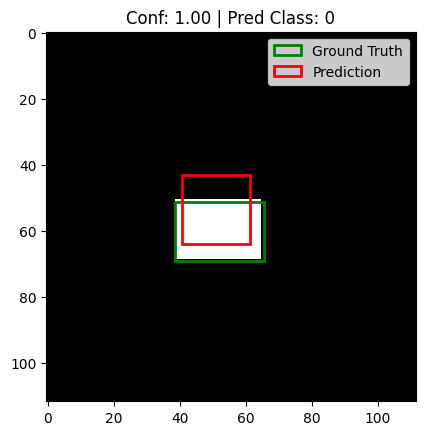

In [4]:
# 保存与加载
torch.save(model.state_dict(), "mini_yolo.pth")
model.load_state_dict(torch.load("mini_yolo.pth"))
model.eval()

# 从验证集取1张图片推理
val_dataset = FakeDetectionDataset(10)
img_tensor, true_box, true_label = val_dataset[0]

with torch.no_grad():
    conf, pred_box, pred_cls = model(img_tensor.unsqueeze(0).to(device))
    
# 解析预测结果 (去掉 Batch 维度并转回 CPU numpy 格式)
conf = conf.item()
pred_box = pred_box.squeeze(0).cpu().numpy()
pred_cls = pred_cls.argmax(dim=1).item()

# --- 关键：可视化检测框 ---
img_size = 112
fig, ax = plt.subplots(1)
# 图片目前是 [3, H, W]，要转为 [H, W, 3] 供 matplotlib 显示
ax.imshow(img_tensor.permute(1, 2, 0).numpy())

# 真实框 (绿色)
tx, ty, tw, th = true_box.numpy() * img_size
rect_true = patches.Rectangle((tx - tw/2, ty - th/2), tw, th, linewidth=2, edgecolor='g', facecolor='none', label='Ground Truth')
ax.add_patch(rect_true)

# 预测框 (红色)
px, py, pw, ph = pred_box * img_size
rect_pred = patches.Rectangle((px - pw/2, py - ph/2), pw, ph, linewidth=2, edgecolor='r', facecolor='none', label='Prediction')
ax.add_patch(rect_pred)

plt.title(f"Conf: {conf:.2f} | Pred Class: {pred_cls}")
plt.legend()
plt.show()

## 步骤 11：目标检测模型的 ONNX 导出

检测模型的导出是最容易报错的，因为有些 NMS 后处理代码包含了 Tensor 转 List 的 Python 特有逻辑，ONNX 无法追踪。

In [ ]:
dummy_input = torch.randn(1, 3, 112, 112, device=device)
onnx_path = "mini_yolo.onnx"
torch.onnx.export(
    model, dummy_input, onnx_path,
    export_params=True, opset_version=11,
    input_names=['input'], 
    # 注意这里，我们有三个输出头！需要分别为它们命名
    output_names=['obj_conf', 'box_preds', 'class_preds'],
    dynamic_axes={'input': {0: 'batch_size'}}
)
print(f"目标检测模型已导出至: {onnx_path}")
print("通常导出的 ONNX 会交给 TensorRT 加速，然后在 C++ 中手动编写 NMS 进行最终画框。")

## 🏆 第三阶段结语
你刚刚手写了一个目标检测网络最核心的**联合回归架构**！真实的 YOLO 只不过是将图片切成了网格，在每个网格上运行了类似的这套逻辑罢了。

目前我们已经攻克了经典的视觉（Vision）领域，请运行这份代码体验你的成果。通过之后向我汇报，我们将直接跨界进入真正的重头戏——**第四阶段：大语言模型的地基（自然语言处理与 Transformer）**！